In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# All assumptions match the Excel model ("Morrisons_LBO_Credit_Analysis.xlsx")
ASSUMPTIONS = {
    # Entry
    "entry_ebitda": 974,          # £m, Year 0 (FY20/21)
    "entry_ev_multiple": 10.3,    # x EBITDA

    # Operating
    "rev0": 17600,                # £m, Year 0 revenue
    "rev_growth": 0.02,
    "margin_improve_pa": 0.003,
    "da_pct_revenue": 0.025,
    "capex_pct_revenue": 0.03,
    "nwc_pct_of_rev_growth": 0.10,
    "tax_rate": 0.25,

    # Debt (sized to ~8.0x entry leverage, matching Fitch's reported figure)
    "term_loan_entry": 2000,
    "term_loan_rate": 0.065,
    "term_loan_amort_pct": 0.01,
    "bonds_entry": 5800,
    "bond_rate": 0.070,
    "cash_sweep_pct": 0.75,

    # Exit
    "exit_year": 5,
    "exit_ev_multiple": 10.3,

    # Covenants (illustrative)
    "max_leverage": 6.5,
    "min_coverage": 2.0,
}

SCENARIOS = {
    "Base Case": 0.00,
    "Moderate Downturn (-15% EBITDA)": 0.15,
    "Severe Downturn (-30% EBITDA)": 0.30,
}

YEARS = [0, 1, 2, 3, 4, 5]

In [2]:
def run_scenario(ebitda_shock: float) -> pd.DataFrame:
    """Runs the 5-year model for one EBITDA stress scenario."""
    a = ASSUMPTIONS
    rows = []

    revenue = a["rev0"]
    margin = a["entry_ebitda"] / a["rev0"]
    term_loan_bal = a["term_loan_entry"]
    bonds_bal = a["bonds_entry"]
    prev_revenue = revenue

    for year in YEARS:
        if year > 0:
            revenue = prev_revenue * (1 + a["rev_growth"])
            margin = margin + a["margin_improve_pa"]

        base_ebitda = revenue * margin
        ebitda = base_ebitda * (1 - ebitda_shock) if year > 0 else base_ebitda

        da = revenue * a["da_pct_revenue"]
        ebit = ebitda - da

        if year == 0:
            interest = 0.0
            term_amort = 0.0
            sweep = 0.0
        else:
            interest = term_loan_bal * a["term_loan_rate"] + bonds_bal * a["bond_rate"]
            term_amort = min(term_loan_bal, a["term_loan_entry"] * a["term_loan_amort_pct"])

        ebt = ebit - interest
        tax = max(0.0, ebt) * a["tax_rate"]
        net_income = ebt - tax

        capex = revenue * a["capex_pct_revenue"]
        nwc_increase = (revenue - prev_revenue) * a["nwc_pct_of_rev_growth"] if year > 0 else 0.0
        fcf_pre_debt_service = net_income + da - capex - nwc_increase

        if year > 0:
            cash_avail_for_sweep = max(0.0, fcf_pre_debt_service - term_amort)
            sweep = min(cash_avail_for_sweep * a["cash_sweep_pct"], term_loan_bal - term_amort)
            term_loan_bal = term_loan_bal - term_amort - sweep

        total_debt = term_loan_bal + bonds_bal
        leverage = total_debt / ebitda if ebitda > 0 else float("inf")
        coverage = (ebitda / interest) if interest > 0 else float("nan")

        rows.append({
            "Year": year, "Revenue": revenue, "EBITDA": ebitda, "Interest": interest,
            "FCF (pre debt service)": fcf_pre_debt_service,
            "Term Loan Balance": term_loan_bal, "Bonds Balance": bonds_bal,
            "Total Debt": total_debt, "Leverage Ratio": leverage,
            "Interest Coverage": coverage,
            "Leverage Breach": leverage > a["max_leverage"],
            "Coverage Breach": (coverage < a["min_coverage"]) if year > 0 else False,
        })
        prev_revenue = revenue

    return pd.DataFrame(rows).set_index("Year")

In [3]:
results = {name: run_scenario(shock) for name, shock in SCENARIOS.items()}

for name, df in results.items():
    print(f"\n--- {name} ---")
    print(df[["EBITDA", "Total Debt", "Leverage Ratio", "Interest Coverage"]].round(2))

    lev_breach = df.index[df["Leverage Breach"]].tolist()
    cov_breach = df.index[df["Coverage Breach"]].tolist()
    print(f"  Leverage covenant breached in Year(s): {lev_breach or 'never'}")
    print(f"  Coverage covenant breached in Year(s): {cov_breach or 'never'}")


--- Base Case ---
       EBITDA  Total Debt  Leverage Ratio  Interest Coverage
Year                                                        
0      974.00     7800.00            8.01                NaN
1     1047.34     7780.00            7.43               1.95
2     1123.22     7760.00            6.91               2.10
3     1201.71     7739.23            6.44               2.25
4     1282.90     7679.24            5.99               2.41
5     1366.85     7577.17            5.54               2.59
  Leverage covenant breached in Year(s): [0, 1, 2]
  Coverage covenant breached in Year(s): [1]

--- Moderate Downturn (-15% EBITDA) ---
       EBITDA  Total Debt  Leverage Ratio  Interest Coverage
Year                                                        
0      974.00      7800.0            8.01                NaN
1      890.24      7780.0            8.74               1.66
2      954.73      7760.0            8.13               1.79
3     1021.46      7740.0            7.58          

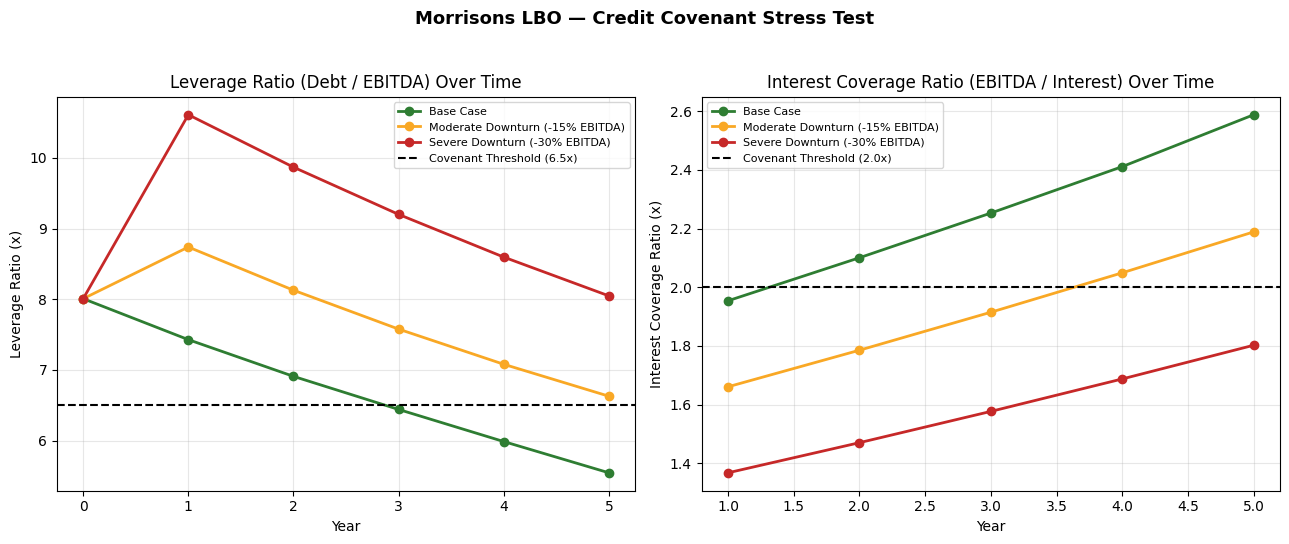

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
colors = {"Base Case": "#2E7D32", "Moderate Downturn (-15% EBITDA)": "#F9A825",
          "Severe Downturn (-30% EBITDA)": "#C62828"}

for name, df in results.items():
    ax1.plot(df.index, df["Leverage Ratio"], marker="o", label=name, color=colors[name], linewidth=2)
ax1.axhline(ASSUMPTIONS["max_leverage"], color="black", linestyle="--", label="Covenant Threshold (6.5x)")
ax1.set_title("Leverage Ratio (Debt / EBITDA) Over Time")
ax1.set_xlabel("Year"); ax1.set_ylabel("Leverage Ratio (x)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

for name, df in results.items():
    plot_df = df.iloc[1:]
    ax2.plot(plot_df.index, plot_df["Interest Coverage"], marker="o", label=name, color=colors[name], linewidth=2)
ax2.axhline(ASSUMPTIONS["min_coverage"], color="black", linestyle="--", label="Covenant Threshold (2.0x)")
ax2.set_title("Interest Coverage Ratio (EBITDA / Interest) Over Time")
ax2.set_xlabel("Year"); ax2.set_ylabel("Interest Coverage Ratio (x)")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

fig.suptitle("Morrisons LBO — Credit Covenant Stress Test", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [5]:
combined = []
for name, df in results.items():
    temp = df[["EBITDA", "Total Debt", "Leverage Ratio", "Interest Coverage",
               "Leverage Breach", "Coverage Breach"]].copy()
    temp.insert(0, "Scenario", name)
    combined.append(temp)
summary_df = pd.concat(combined)
summary_df.to_csv("stress_test_summary.csv")

from google.colab import files
files.download("stress_test_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>